In [ ]:
# Plant Disease Detector — Week 5

## CNN Model Training

In this week, the CNN model developed in Week 4 is trained using the PlantVillage dataset.

### Objectives
- Load the PlantVillage dataset
- Split images into training and validation sets
- Train the CNN model
- Monitor training and validation accuracy
- Evaluate the trained model

In [1]:
import tensorflow as tf
import os

# Dataset path
data_dir = r"C:\Users\SARVAJEETH\OneDrive\Desktop\edp weeks\dataset\PlantVillage\PlantVillage"

# Image and batch settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Get class names
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print("Classes:", class_names)


Found 20637 files belonging to 15 classes.
Using 16510 files for training.
Found 20637 files belonging to 15 classes.
Using 4127 files for validation.
Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [2]:
from tensorflow.keras import layers, models

# Build CNN model
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(15, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)     

In [3]:
# Train the CNN model

EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5


516/516 [==============================] - 471s 909ms/step - loss: 1.1514 - accuracy: 0.6348 - val_loss: 0.5648 - val_accuracy: 0.8207
Epoch 2/5
516/516 [==============================] - 514s 996ms/step - loss: 0.4332 - accuracy: 0.8570 - val_loss: 0.3890 - val_accuracy: 0.8709
Epoch 3/5
516/516 [==============================] - 490s 950ms/step - loss: 0.2281 - accuracy: 0.9245 - val_loss: 0.5544 - val_accuracy: 0.8282
Epoch 4/5
516/516 [==============================] - 481s 932ms/step - loss: 0.1499 - accuracy: 0.9511 - val_loss: 0.4404 - val_accuracy: 0.8699
Epoch 5/5
516/516 [==============================] - 479s 927ms/step - loss: 0.0980 - accuracy: 0.9681 - val_loss: 0.4135 - val_accuracy: 0.8839


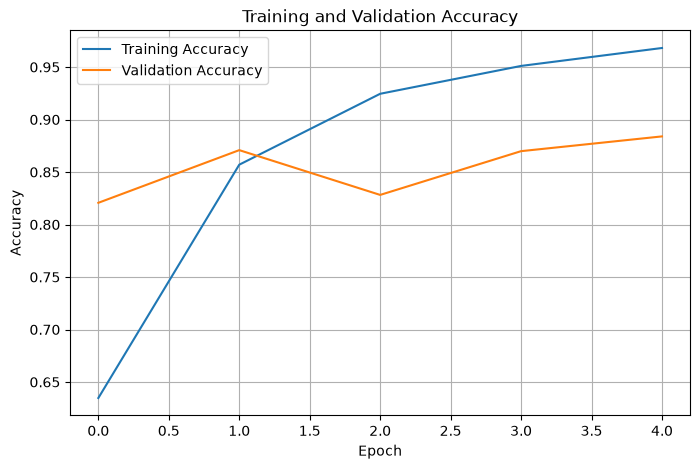

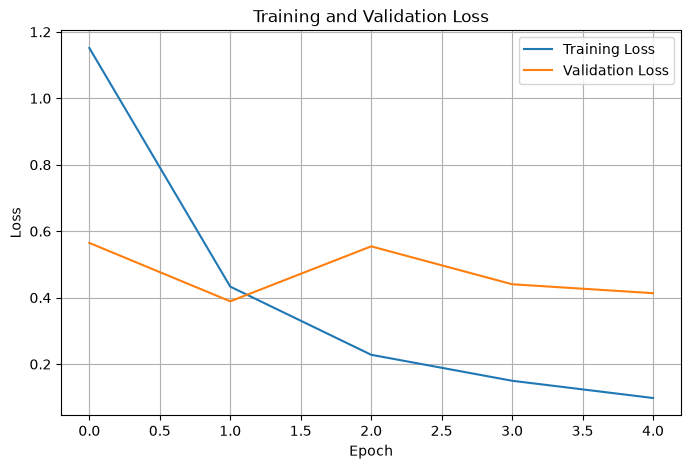

In [5]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Evaluate the trained model on the validation dataset

val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print("\nFinal Validation Loss:", val_loss)
print("Final Validation Accuracy:", val_accuracy)
print("Final Validation Accuracy (%):", val_accuracy * 100)

129/129 [==============================] - 24s 182ms/step - loss: 0.4135 - accuracy: 0.8839

Final Validation Loss: 0.41349712014198303
Final Validation Accuracy: 0.8839350342750549
Final Validation Accuracy (%): 88.3935034275055


In [7]:
# Save the trained CNN model

model_path = "plant_disease_cnn.keras"

model.save(model_path)

print("Model saved successfully!")
print("Saved as:", model_path)

Model saved successfully!
Saved as: plant_disease_cnn.keras


# Week 5 Results

## CNN Training Summary

The Plant Disease Detection CNN was trained using the PlantVillage dataset.

### Dataset
- Total images: 20,637
- Number of classes: 15
- Training images: 16,510
- Validation images: 4,127
- Image size: 224 × 224
- Batch size: 32

### Training
- Model: Convolutional Neural Network (CNN)
- Optimizer: Adam
- Loss function: Sparse Categorical Crossentropy
- Epochs: 5

### Final Performance
- Training Accuracy: 96.81%
- Validation Accuracy: 88.39%
- Validation Loss: 0.4135

### Model Output
The trained model was saved as:

`plant_disease_cnn.keras`

## Conclusion

The CNN successfully learned to classify plant diseases from the PlantVillage dataset. The model achieved a validation accuracy of approximately 88.39%, demonstrating good performance on unseen validation images.